## 7/12 ge calibration

T1 = 36e-06

T2_echo = 5.5e-06

T2_star = 4.8e-06

In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

In [4]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [6]:
header = "D:/K_Sunada/result/CDY162/"

In [37]:
amp = "/2024-07-12/2024-07-12T125826_fd95558e-21_ge_pi_amp"
dd_amp = datadict_from_hdf5(header + amp +"/data")

In [38]:
Rabi_amp = dd_amp['s11']['values']
imag_amp = Rabi_amp.imag
amp = dd_amp['amplitude']['values']

In [39]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2, pca

In [41]:
I_amp = (Rabi_amp.real)
Q_amp = (Rabi_amp.imag)
PCA_amp = PCA_transform(I_amp, Q_amp)


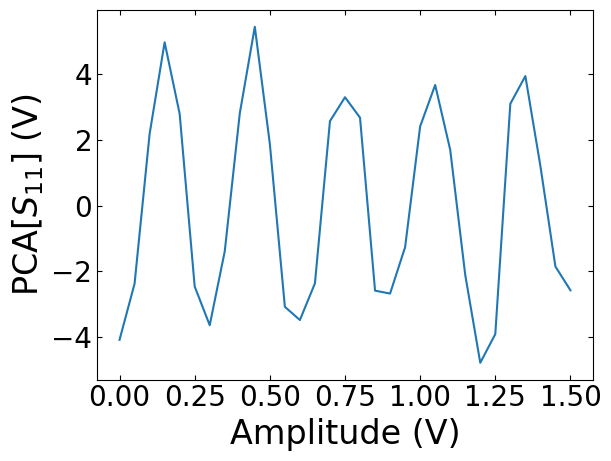

In [42]:
PCA_amp = PCA_transform(I_amp, Q_amp)
y = I_amp
x = amp

fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Amplitude (V)', size='large')
ax1.set_ylabel('PCA[$S_{11}$] (V)', size='large')
plt.rcParams["font.size"] = 17
plt.plot(x, PCA_amp[0])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 1)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )
plt.show()

In [43]:
par_ini= {
    'amp': 5,
    'phi0':0,
    'detun':1/0.27,
    'const':0
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.inf
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [44]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result = model.fit(data = PCA_amp[0], params = params, delay = x)
result

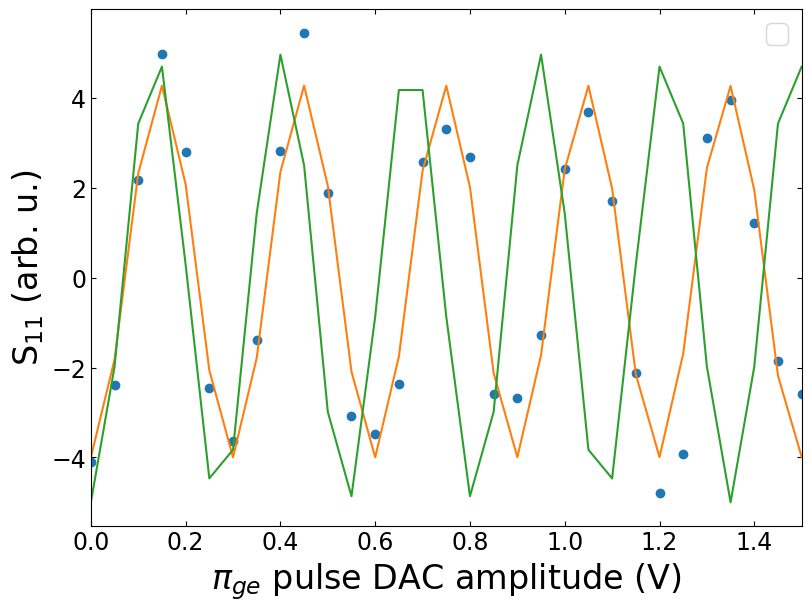

In [45]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(x,result.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel('$\pi_{ge}$ pulse DAC amplitude (V)', size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)', size='large')
ax.set_xlim(0, 1.5)
# plt.savefig('ge_rabi.png', bbox_inches='tight')
plt.show()

In [46]:
np.pi/(3.33787410*2*np.pi)*5

0.7489797173596212

ramsey

In [53]:
pl ="/2024-07-12/2024-07-12T125958_34be571c-23_ge_T2r1d"
mi = "/2024-07-12/2024-07-12T130035_4af06242-23_ge_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

In [54]:
Rabi_pl = dd_pl['s11']['values']
imag_pl = Rabi_pl.imag
delay_pl = dd_pl['delay']['values']

Rabi_mi = dd_mi['s11']['values']
imag_mi = Rabi_mi.imag
delay_mi = dd_mi['delay']['values']

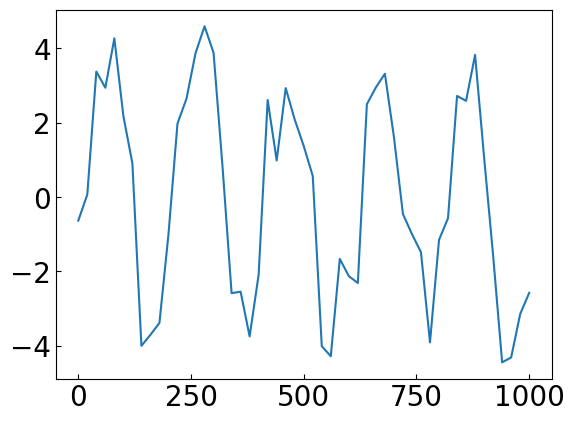

In [55]:
I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)


PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi



plt.plot(x_pl, y_pl)
plt.show()

In [50]:
par_ini_pl = {
    'amp': 5,
    'phi0':0,
    'detun':1/200,
    'const':0.1
}

par_min_pl = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_pl = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_pl = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [51]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_pl[name],
    min = par_min_pl[name],
    max = par_max_pl[name],
    vary = par_vary_pl[name]
    )
    
result_pl = model.fit(data = y_pl, params = params, delay = x_pl)
result_pl

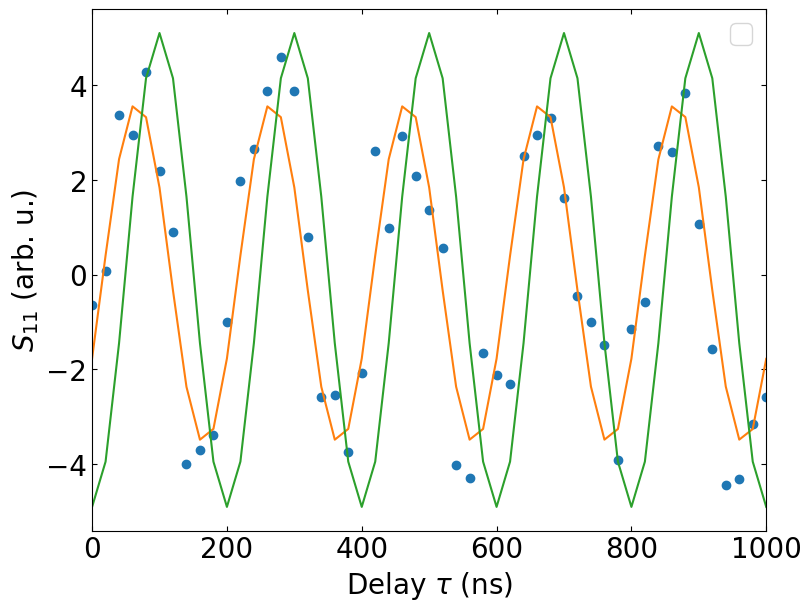

In [52]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)

# plt.title("Rabi(+5MHz)")


plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

result_pl.plot_fit(ax = ax)
plt.plot(x_pl,result_pl.init_fit)
plt.title("")
plt.legend("")
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")
plt.xlim(0, 1000)
# plt.savefig('ge_ramsey.png', bbox_inches='tight')

plt.show()

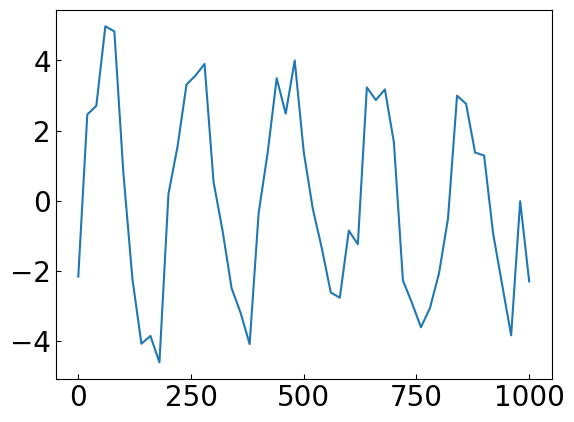

In [56]:
plt.plot(x_mi, y_mi)
plt.show()

In [57]:
par_ini_mi = {
    'amp': 5,
    'phi0':np.pi/2,
    'detun':1/200,
    'const':0.1
}

par_min_mi = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_mi = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_mi = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [58]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_mi[name],
    min = par_min_mi[name],
    max = par_max_mi[name],
    vary = par_vary_mi[name]
    )
    
result_mi = model.fit(data = y_mi, params = params, delay = x_mi)
result_mi

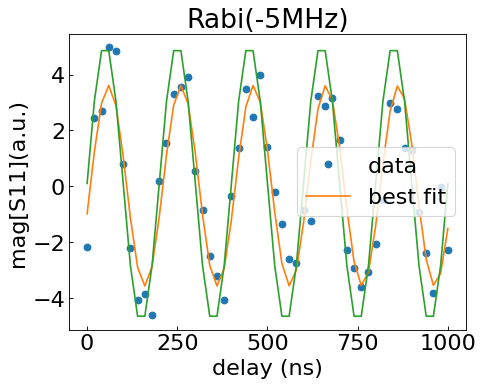

In [59]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(-5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_mi.plot_fit(ax = ax)
plt.plot(x_mi,result_mi.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()


In [60]:
detun = ((0.005-0.00499958)+ (0.00497484-0.005))/2 #GHz
detun

-1.2369999999999829e-05

drag

In [79]:
drag = "/2024-06-14/2024-06-14T152316_963b809f-22_ge_pi_drag" # n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2024-06-14/2024-06-14T152632_0b094951-22_ge_pi_drag" # n=13
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2024-06-14/2024-06-14T152835_54543018-22_ge_pi_drag" # n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [80]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [81]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

In [82]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

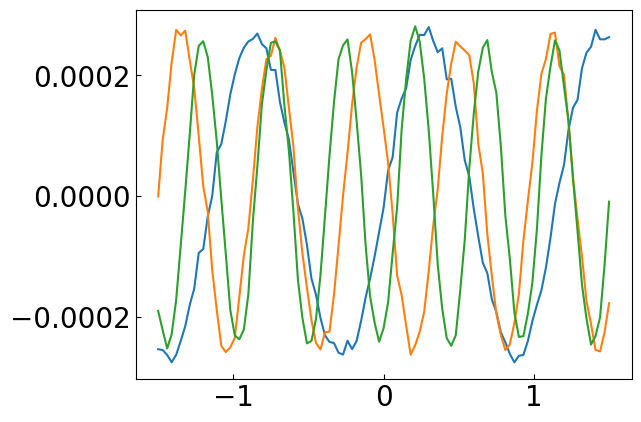

In [83]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [109]:
par_ini= {
    'amp': 0.0003,
    'phi0':0,
    'detun':1/0.5,
    'const':0.,
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.pi
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [110]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [95]:
result0

In [97]:
res0 = (2*np.pi-1.53162347)/(2*np.pi*0.86658801)
res0

0.8726575316844493

In [106]:
result1

In [108]:
res1 = (2*np.pi+2.01190763)/(2*np.pi*1.62057837)
res1

0.8146505400777377

In [112]:
result2

In [115]:
res2 = (4*np.pi-0.34068936)/(2*np.pi*2.12281049)
res2

0.916604479515826

In [116]:
beta = (res0 + res1 + res2)/3
beta

0.8679708504260044

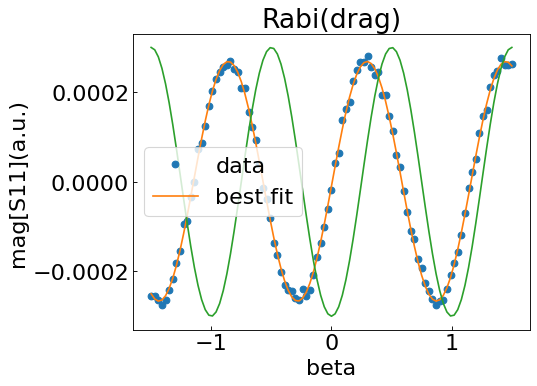

In [94]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

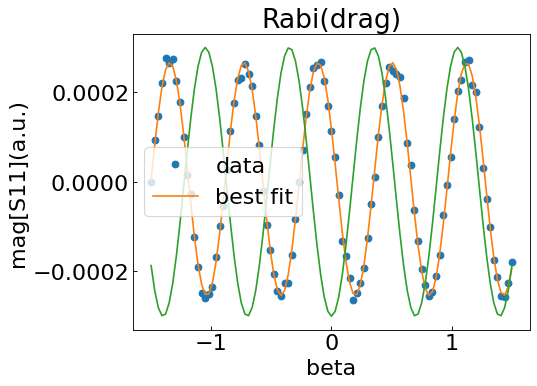

In [104]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

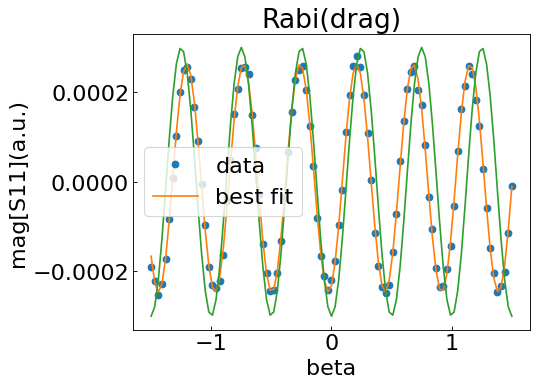

In [111]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


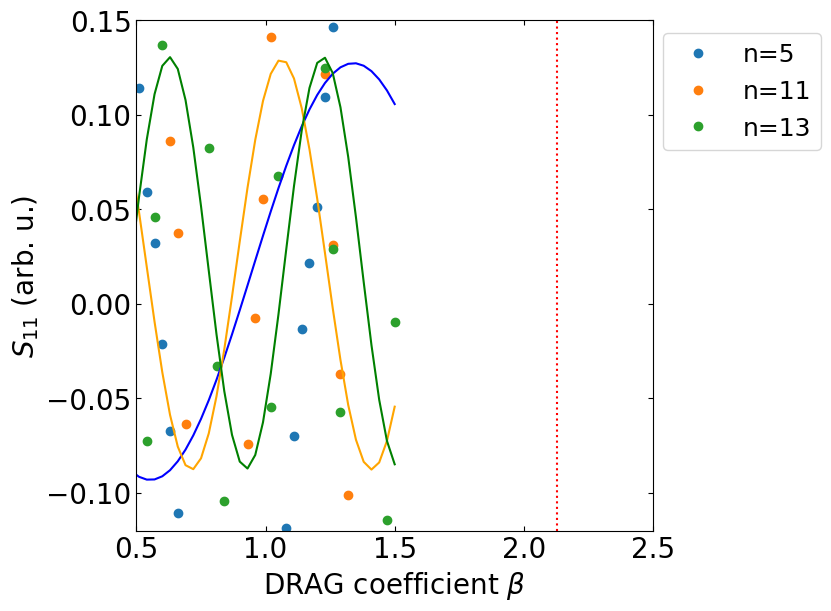

In [99]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.plot(x0, y0*1e3, 'o', label="n=5")
plt.plot(x0, y1*1e3, 'o', label="n=11")
plt.plot(x0, y2*1e3, 'o', label="n=13")
plt.plot(x0, (1.7083e-5-1.1027e-4*np.cos(2*np.pi*0.63526460*x0+4.07498125))*1e3, color='blue')
plt.plot(x0, (2.0782e-5-1.0850e-4*np.cos(2*np.pi*1.43345157*x0-0.13875923))*1e3, color='orange')
plt.plot(x0, (2.1621e-5-1.0893e-4*np.cos(2*np.pi*1.68136672*x0-3.48994880))*1e3, color='green')
plt.vlines(2.129117898677454, -0.12, 0.15, color='r', linestyles='dotted')
plt.ylim(-0.12, 0.15)
plt.xlim(0.5, 2.5)

plt.title("")
plt.legend(title_fontsize=18, fontsize=18, loc='upper right', bbox_to_anchor=(1.35, 1))
plt.xlabel(r"DRAG coefficient ${\beta}$")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('drag_ge_pi.png', bbox_inches='tight')

plt.show()

half drag

In [117]:
drag = "/2024-06-14/2024-06-14T153611_640619aa-22_ge_pi_drag" # n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2024-06-14/2024-06-14T153659_80738942-22_ge_pi_drag" # n=13
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2024-06-14/2024-06-14T153808_a9a750ce-22_ge_pi_drag" # n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [118]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [119]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

In [120]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

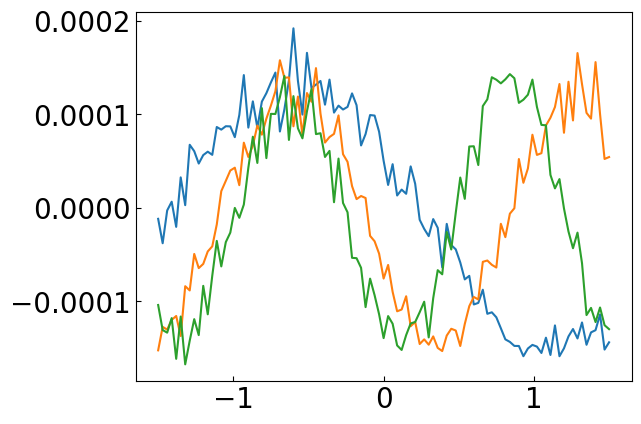

In [121]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [123]:
par_ini= {
    'amp': 2e-4,
    'phi0':-np.pi/2,
    'detun':1/2,
    'const':0.0
}
par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.inf
}
par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}
par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [124]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [129]:
result0

In [131]:
res0 = (-np.pi+2.07323398)/(2*np.pi*0.29018893)
res0

-0.5859443497617787

In [132]:
result1

In [134]:
res1 = (-np.pi+1.14163085)/(2*np.pi*0.52235567)
res1

-0.6093622129846851

In [135]:
result2

In [136]:
res2 = (-np.pi+0.47749756)/(2*np.pi*0.68196294)
res2

-0.6217403881385125

In [137]:
beta = (res0 + res1 + res2)/3
beta

-0.6056823169616586

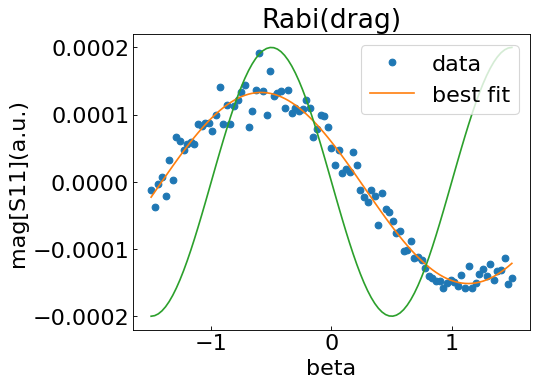

In [126]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

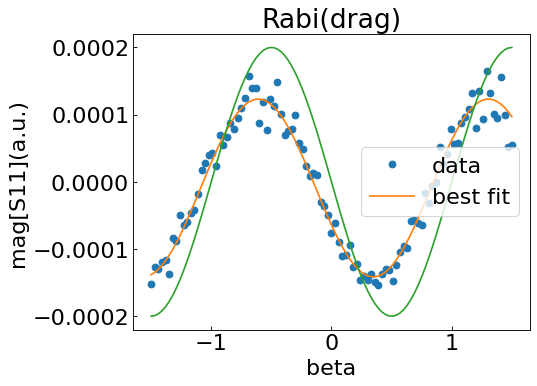

In [127]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

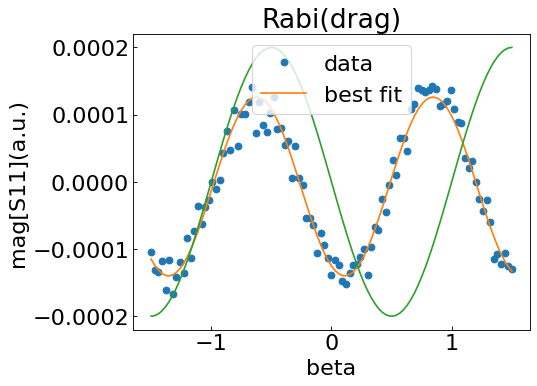

In [128]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


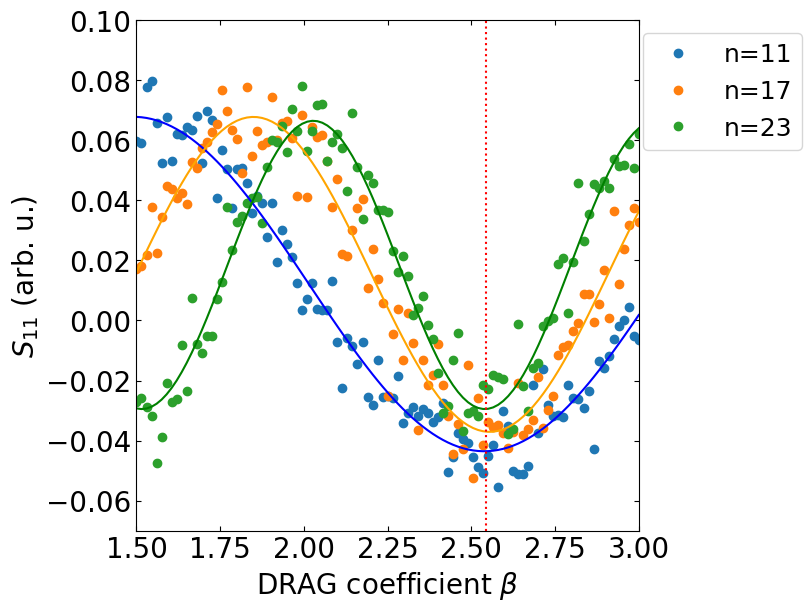

In [136]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.plot(x0, y0*1e3, 'o', label="n=11")
plt.plot(x0, y1*1e3, 'o', label="n=17")
plt.plot(x0, y2*1e3, 'o', label="n=23")
plt.plot(x0, (1.2144e-5-5.5709e-5*np.cos(2*np.pi*0.47743047*x0+4.95160969))*1e3, color='blue')
plt.plot(x0, (1.5352e-5-5.2466e-5*np.cos(2*np.pi*0.70875990*x0+1.18869153))*1e3, color='orange')
plt.plot(x0, (1.8510e-5-4.8021e-5*np.cos(2*np.pi*0.97589009*x0-3.01057149))*1e3, color='green')
plt.vlines(2.5445789598717314, -0.07, 0.1, color='r', linestyles='dotted')
plt.ylim(-0.07, 0.1)
plt.xlim(1.5, 3)

plt.title("")
plt.legend(title_fontsize=18, fontsize=18, loc='upper right', bbox_to_anchor=(1.35, 1))
plt.xlabel(r"DRAG coefficient ${\beta}$")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('drag_ge_half_pi.png', bbox_inches='tight')

plt.show()

T1

In [65]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2024-07-12/2024-07-12T130259_a0c93876-24_ge_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

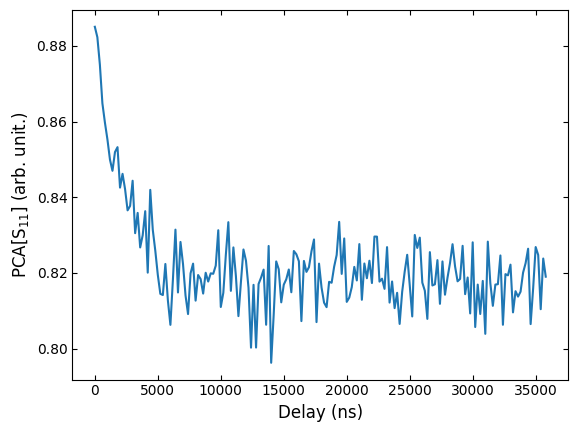

In [66]:
s11_t1 = dd_t1['s11']['values'][0:180]
phase_t1 = s11_t1.imag
delay_t1 = dd_t1['delay']['values'][0:180]

I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)
ang_t1 = np.angle(s11_t1)

PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Delay (ns)', size='large')
ax1.set_ylabel('PCA[S$_{11}$] (arb. unit.)', size='large')
plt.rcParams["font.size"] = 10
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 250000)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

plt.plot(x_t1, -ang_t1)
plt.show()

In [67]:
par_ini_t1 = {
    'gamma': 1/10000e-3,
    'amp':0.25,
    'const':2.8
}

par_min_t1 = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t1 = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t1 = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [68]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = -ang_t1, params = params, delay = x_t1*1e-3)
result_t1

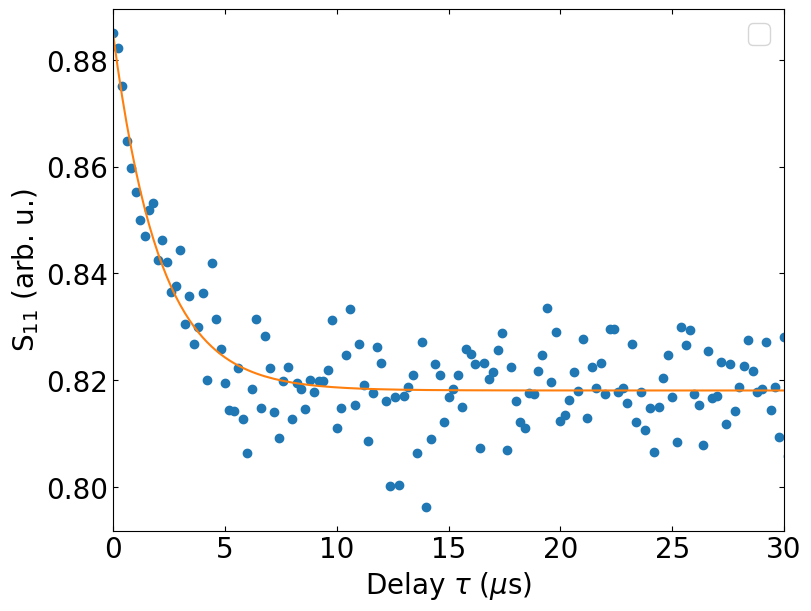

In [71]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

result_t1.plot_fit(ax = ax)
# plt.plot(x_t1,result_t1.init_fit, label='init fit')

# ax.set_ylim(-8, 15)
plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')#, size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)')
plt.xlim(0, 30)
# plt.savefig('ge_T1.png', bbox_inches='tight')
plt.show()

In [74]:
T1 = (1/0.47511183)*1e-6
T1

2.1047676291284936e-06

T2_echo

In [75]:
t2e = "/2024-07-12/2024-07-12T130735_4549db93-25_ge_T2e"
dd_t2e = datadict_from_hdf5(header + t2e +"/data")

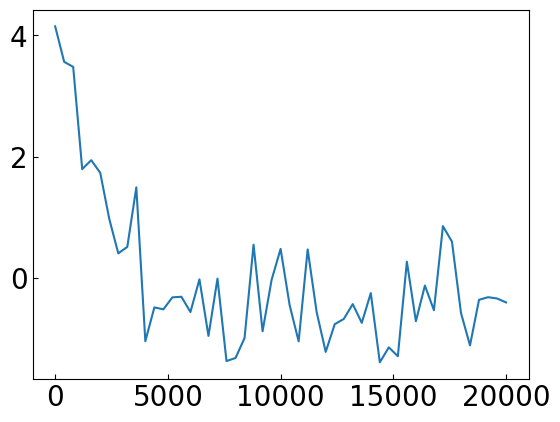

In [76]:
s11_t2e = dd_t2e['s11']['values']
imag_t2e = s11_t2e.imag
delay_t2e = dd_t2e['delay']['values']

I_t2e = (s11_t2e.real)
Q_t2e = (s11_t2e.imag)

PCA_t2e = PCA_transform(I_t2e, Q_t2e)

y_t2e = PCA_t2e[0]
x_t2e = delay_t2e

plt.plot(x_t2e, y_t2e)
plt.show()

In [78]:
par_ini_t2e = {
    'gamma': 1/5000e-3,
    'amp':10,
    'const':0
}

par_min_t2e = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t2e = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t2e = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [79]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2e[name],
    min = par_min_t2e[name],
    max = par_max_t2e[name],
    vary = par_vary_t2e[name]
    )
result_t2e = model.fit(data = y_t2e, params = params, delay = x_t2e*1e-3)
result_t2e

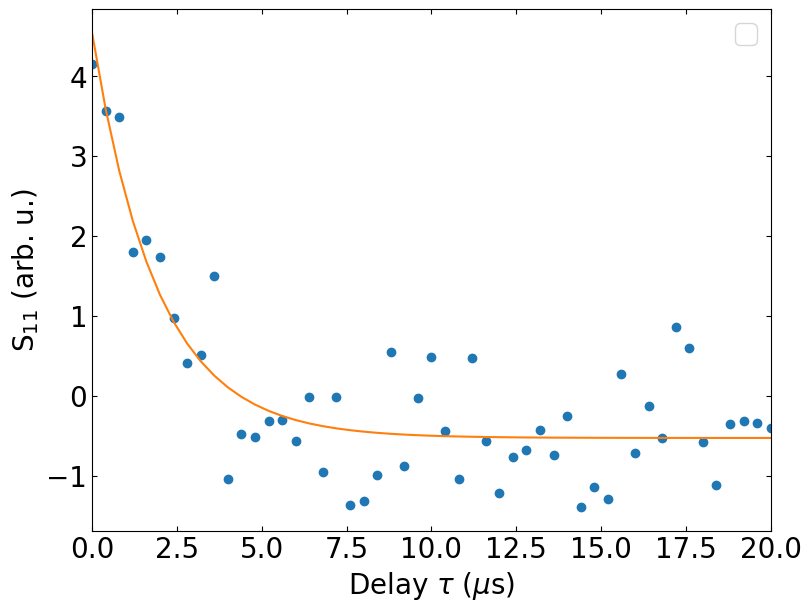

In [81]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2e.plot_fit(ax = ax)
# plt.plot(delay_t2e,result_t2e.init_fit)

# ax.set_ylim(-10, 35)

plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')
ax.set_ylabel('S$_{11}$ (arb. u.)')
plt.xlim(0, 20)
# plt.savefig('ge_T2e.png', bbox_inches='tight')
plt.show()

In [82]:
T2 = (1/0.51962509)*1e-6
T2

1.924464424918358e-06

T2 star

In [83]:
def Damping(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

In [84]:
t2 = "/2024-07-12/2024-07-12T131032_aed2e160-23_ge_T2r1d"
dd_t2 = datadict_from_hdf5(header + t2 +"/data")

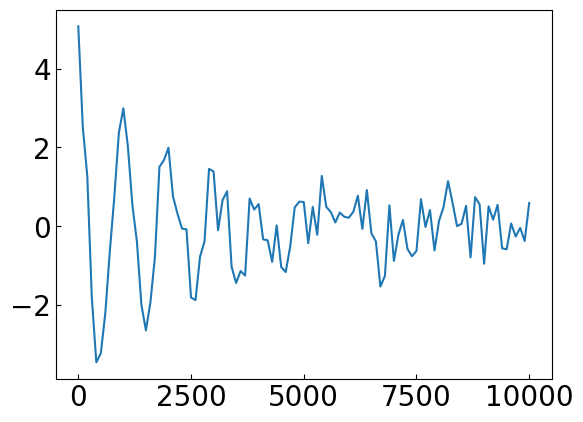

In [85]:
s11_t2 = dd_t2['s11']['values']
imag_t2 = s11_t2.imag
delay_t2 = dd_t2['delay']['values']

I_t2 = (s11_t2.real)
Q_t2 = (s11_t2.imag)

PCA_t2 = PCA_transform(I_t2, Q_t2)

y_t2 = PCA_t2[0]
x_t2 = delay_t2

plt.plot(x_t2, y_t2)
plt.show()

In [86]:
par_ini_t2 = {
    'amp':5,
    'gamma': 1/25000e-3,
    'omega':2*np.pi/1250e-3,
    'phi0':np.pi,
    'const':0
}

par_min_t2 = {
    'amp':-np.inf,
    'gamma': 0,
    'omega':-2*np.pi,
    'phi0':-2*np.pi,
    'const':-np.inf
}

par_max_t2 = {
    'amp':np.inf,
    'gamma': np.inf,
    'omega':2*np.pi,
    'phi0':2*np.pi,
    'const':np.inf
}

par_vary_t2 = {
    'amp':True,
    'gamma': True,
    'omega':True,
    'phi0':True,
    'const':True
}

In [87]:
model = lmfit.Model(Damping)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2[name],
    min = par_min_t2[name],
    max = par_max_t2[name],
    vary = par_vary_t2[name]
    )
result_t2 = model.fit(data = y_t2, params = params, delay = x_t2*1e-3)
result_t2

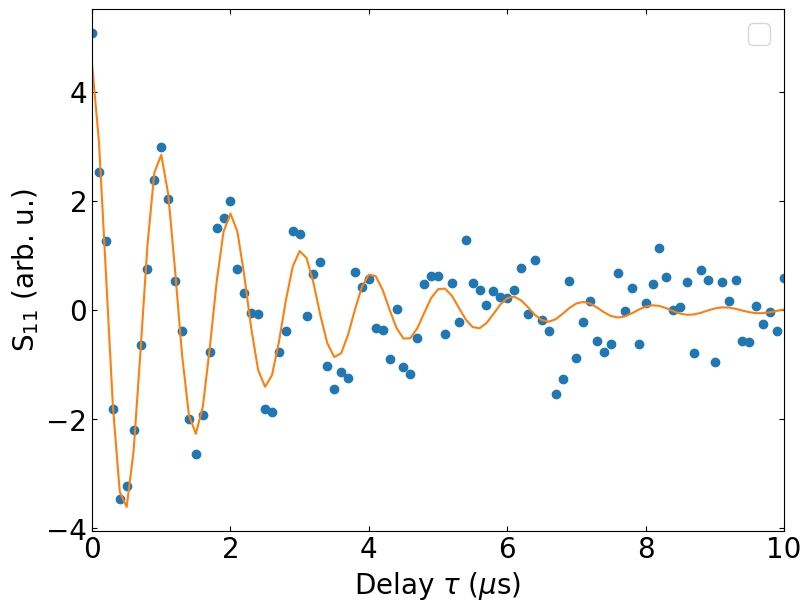

In [89]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2.plot_fit(ax = ax)
# plt.plot(delay_t2,result_t2.init_fit)
# ax.set_ylim(-10, 35)
plt.title("")
plt.legend("")
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')
ax.set_ylabel('S$_{11}$ (arb. u.)')
ax.set_xlim(0, 10)
# plt.savefig('ge_T2star.png', bbox_inches='tight')
plt.show()

In [90]:
T2_star = (1/0.47228650)*1e-6
T2_star

2.1173588489190355e-06